In [ ]:
import ast

s = '''
match x:
    case Point.Var(P(), "y"):
        pass

'''

print(ast.dump(ast.parse(s), indent=2))

In [ ]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy
def f(x: int) -> int:
    y = x + 1
    return y

@guppy
def main(a: int, b: bool, c : bool) -> None:
    if b == c or a > 10 or 2.3 < 3.4:
        pass
    
    d = 2 == 42
main.compile_function().modules[0].render_dot()

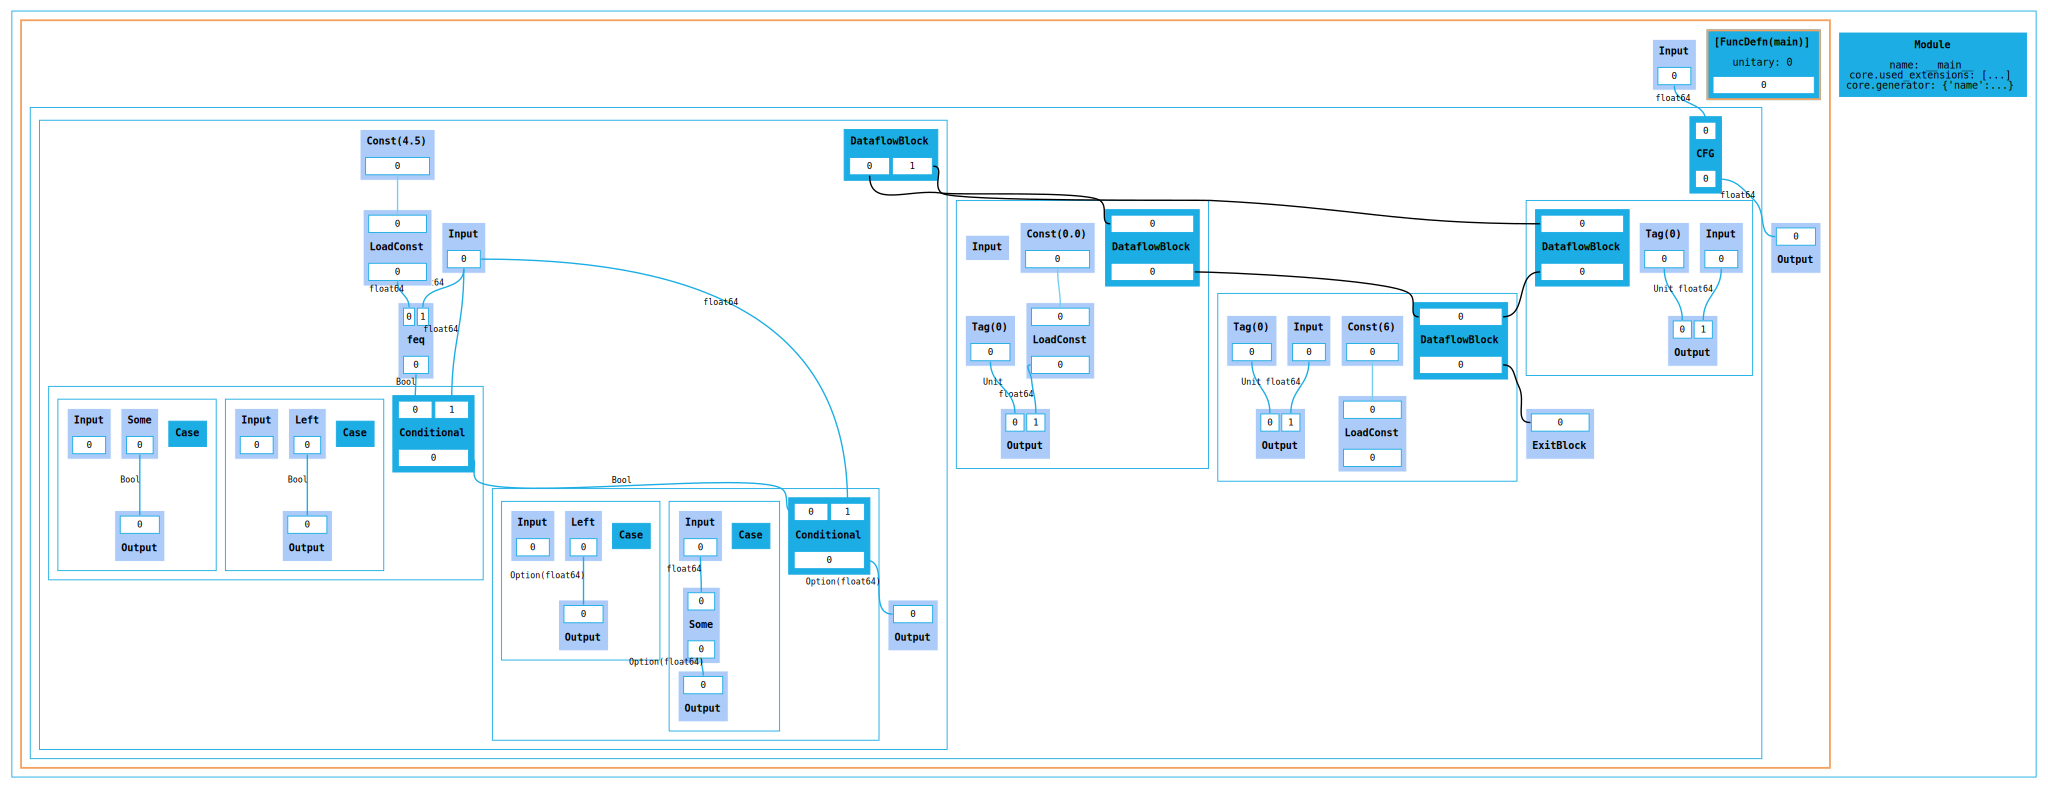

In [7]:

from guppylang import guppy

@guppy
def main(x:float) -> float:
    match x:
        case 4.5:
            x = 0.0

        

    y = 6
    return x


main.compile_function().modules[0].render_dot()

In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h


@guppy.struct
class Point:
    y: int

@guppy
def fun() -> Point:
    return Point( 4)

@guppy
def main(p: Point) -> None:
    s = Point(0)
    if s == p:
        pass


main.compile_function()


In [ ]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h
from selene_hugr_qis_compiler import check_hugr

@guppy.enum
class Point:
    x = {"n": int}

    @guppy
    def a(self:Point) -> None:
        pass

@guppy.struct
class Struct:
    x: int

@guppy
def fun() -> Point:
    return Point.x(qubit())

@guppy
def main(p: Struct) -> None:
    match p:
        case _:
            x = 8
    
    s = Point.x(p.x)
    s.a()

h = main.compile_function()
check_hugr(h.to_bytes())

h.modules[0].render_dot()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, h

@guppy.struct
class Point:
    x: qubit
    y: int

@guppy
def fun() -> Point:
    return Point(qubit(), 4)

@guppy
def describe_point(point: Point)-> None:
    pass

@guppy
def main(p: Point) -> None:

    describe_point(fun())

main.check()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure

@guppy.enum
class Point:
    x = {"n": bool}
    y = {"n": int}

    @guppy
    def met(self: Point) -> int:
@guppy.enum
class Point:
    x = {"n": bool}
    y = {"n": int}

    @guppy
    def met(self: Point) -> int:
        match self:
            case Point.x(True):
                return 42
            case Point.y(val):
                return val
            case Point.y(_):
                return 2
            case Point.y(val):
                return val
            case Point.y(_):
                return 2


@guppy
def main(p: Point) -> None:
    e = Point.y(1)
    e.met()

    # describe_point(fun())

main.compile_function().modules[0].render_dot().view()


In [ ]:
from guppylang import guppy

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def main(p: Point) -> None:
    match p:
        case Point(_, _):
            b = 1
    a = b

main.check()

In [ ]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.enum
class Point:
    x = {"n": int}
    y = {"n": int}
    z = {"n": int}

    @guppy
    def enum(self: Point) -> None:
        pass

@guppy.struct
class Line:
    start: int
    end: int

    @guppy
    def struct(self: Line) -> None:
        pass

@guppy
def main() -> None:
    p = Point.x(1)
    p.enum()
    l = Line(2, 3)
    l.struct()

main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100)).view()
    